import libraries

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# warnings

import warnings
warnings.filterwarnings('ignore')



In [12]:
import os

### **data**

In [13]:
file_path = os.path.join('flights.csv')  # since CSV is in the same folder as notebook
data = pd.read_csv(file_path)
pd.set_option('display.max_columns',None) # display all columns

In [14]:
data.columns

Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency', 'date'],
      dtype='object')

In [15]:
data.head(3)

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,09/26/2019
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,09/30/2019
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,10/03/2019


In [16]:
print('ROWS = ' ,data.shape[0],'\nCOLUMNS = ' , data.shape[1])

ROWS =  271888 
COLUMNS =  10


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   travelCode  271888 non-null  int64  
 1   userCode    271888 non-null  int64  
 2   from        271888 non-null  object 
 3   to          271888 non-null  object 
 4   flightType  271888 non-null  object 
 5   price       271888 non-null  float64
 6   time        271888 non-null  float64
 7   distance    271888 non-null  float64
 8   agency      271888 non-null  object 
 9   date        271888 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 20.7+ MB


In [18]:
data.duplicated().sum()

np.int64(0)

In [19]:
data.isnull().sum()

travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64

In [20]:
data.isnull().mean()*100 # missing value percentage

travelCode    0.0
userCode      0.0
from          0.0
to            0.0
flightType    0.0
price         0.0
time          0.0
distance      0.0
agency        0.0
date          0.0
dtype: float64

In [21]:
data.drop(['travelCode','userCode'],axis = 1).describe()

,price,time,distance
count,271888.00000,271888.000000,271888.000000
mean,957.37503,1.421147,546.955535
std,362.31189,0.542541,208.851288
min,301.51000,0.440000,168.220000
25%,672.66000,1.040000,401.660000
50%,904.00000,1.460000,562.140000
75%,1222.24000,1.760000,676.530000
max,1754.17000,2.440000,937.770000


In [22]:
# check count of unique values
data.nunique()

travelCode    135944
userCode        1335
from               9
to                 9
flightType         3
price            490
time              33
distance          35
agency             3
date             999
dtype: int64

In [23]:
data['agency'].unique()

array(['FlyingDrops', 'CloudFy', 'Rainbow'], dtype=object)

In [24]:
data['from'].unique()

array(['Recife (PE)', 'Florianopolis (SC)', 'Brasilia (DF)',
       'Aracaju (SE)', 'Salvador (BH)', 'Campo Grande (MS)',
       'Sao Paulo (SP)', 'Natal (RN)', 'Rio de Janeiro (RJ)'],
      dtype=object)

In [25]:
data['to'].unique()

array(['Florianopolis (SC)', 'Recife (PE)', 'Brasilia (DF)',
       'Salvador (BH)', 'Aracaju (SE)', 'Campo Grande (MS)',
       'Sao Paulo (SP)', 'Natal (RN)', 'Rio de Janeiro (RJ)'],
      dtype=object)

In [26]:
data['flightType'].unique()

array(['firstClass', 'economic', 'premium'], dtype=object)

### **date conversion**

In [27]:
# date conversion
data['date'] = pd.to_datetime(data['date'], errors = 'coerce')

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271888 entries, 0 to 271887
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   travelCode  271888 non-null  int64         
 1   userCode    271888 non-null  int64         
 2   from        271888 non-null  object        
 3   to          271888 non-null  object        
 4   flightType  271888 non-null  object        
 5   price       271888 non-null  float64       
 6   time        271888 non-null  float64       
 7   distance    271888 non-null  float64       
 8   agency      271888 non-null  object        
 9   date        271888 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 20.7+ MB


In [29]:
data['day_name'] = data['date'].dt.day_name()
data['day'] = data['date'].dt.dayofweek

In [30]:
data['month_name'] = data['date'].dt.month_name()
data['month'] = data['date'].dt.month

In [31]:
# is weekend or not
data['is_weekend'] = data['day'].apply(lambda x : 1 if x >= 1 else 0)

In [32]:
data['minutes'] = data['time'].apply(lambda x : x*60)

### **route conversion**

In [33]:
data['route'] = data['from'] + '-->' + data['to']

In [34]:
data['route'].value_counts()

route
Florianopolis (SC)-->Aracaju (SE)         8643
Aracaju (SE)-->Florianopolis (SC)         8643
Florianopolis (SC)-->Campo Grande (MS)    8253
Campo Grande (MS)-->Florianopolis (SC)    8253
Florianopolis (SC)-->Brasilia (DF)        7779
                                          ... 
Natal (RN)-->Rio de Janeiro (RJ)           950
Sao Paulo (SP)-->Rio de Janeiro (RJ)       934
Rio de Janeiro (RJ)-->Sao Paulo (SP)       934
Natal (RN)-->Salvador (BH)                 926
Salvador (BH)-->Natal (RN)                 926
Name: count, Length: 70, dtype: int64

### **distance and time**

In [35]:
# speed
data['speed'] = data['distance'] / data['time']

In [36]:
# price per kilometer
data['price_per_km'] = data['price'] / data['distance']

In [37]:
# price per hour
data['price_for_hour'] = data['price'] / data['time']

### **price bucket**

In [38]:
# price bucket
def range(n):
  if n < 600:
    return 'LOW'
  elif 600 <= n< 1000:
    return 'MEDIUM'
  elif 1000 <= n < 1400:
    return 'HIGH'
  else:
    return 'VERY HIGH'



In [39]:
data['price_bucket'] = data['price'].apply(range)

### **EDA**

### 1. price vs flight type and agency

   flightType        price
1  firstClass  1181.067727
2     premium   920.392375
0    economic   658.443093
                                                                              
        agency        price
1  FlyingDrops  1186.160378
2      Rainbow   919.780760
0      CloudFy   918.896483


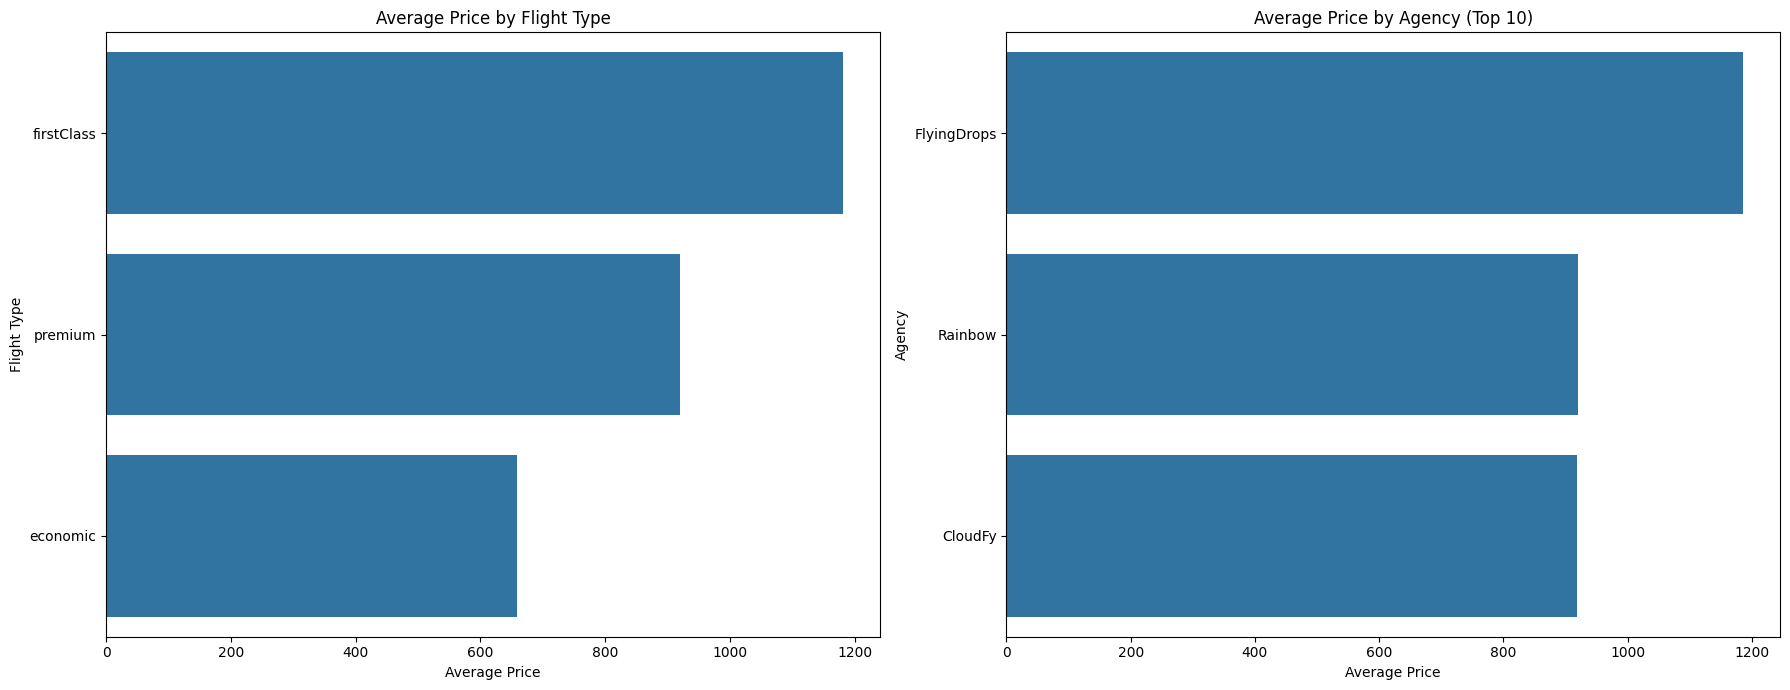

In [40]:
price_flight_type = data.groupby('flightType')['price'].mean().reset_index().sort_values('price',ascending = False)
print(price_flight_type)
print('                                                                              ')
price_agency = data.groupby('agency')['price'].mean().reset_index().sort_values('price',ascending = False)
print(price_agency)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Price vs Flight Type
sns.barplot(x='price',y='flightType',data=price_flight_type,ax=axes[0] )
axes[0].set_title('Average Price by Flight Type')
axes[0].set_xlabel('Average Price')
axes[0].set_ylabel('Flight Type')

# Plot 2: Price vs Agency
sns.barplot(x='price',y='agency', data=price_agency, ax=axes[1] )
axes[1].set_title('Average Price by Agency (Top 10)')
axes[1].set_xlabel('Average Price')
axes[1].set_ylabel('Agency')

plt.tight_layout()
plt.show()

### **2. price vs route and most used routes**

                                    route  count
0       Florianopolis (SC)-->Aracaju (SE)   8643
1       Aracaju (SE)-->Florianopolis (SC)   8643
2  Florianopolis (SC)-->Campo Grande (MS)   8253
3  Campo Grande (MS)-->Florianopolis (SC)   8253
4      Florianopolis (SC)-->Brasilia (DF)   7779
5      Brasilia (DF)-->Florianopolis (SC)   7779
6        Recife (PE)-->Florianopolis (SC)   7609
7        Florianopolis (SC)-->Recife (PE)   7609
8     Sao Paulo (SP)-->Florianopolis (SC)   6717
9     Florianopolis (SC)-->Sao Paulo (SP)   6717
                                                                     
                                     route   price
0      Sao Paulo (SP)-->Florianopolis (SC)  1381.0
1  Campo Grande (MS)-->Rio de Janeiro (RJ)  1371.0
2            Brasilia (DF)-->Salvador (BH)  1367.0
3             Aracaju (SE)-->Salvador (BH)  1365.0
4        Rio de Janeiro (RJ)-->Recife (PE)  1361.0
5               Natal (RN)-->Salvador (BH)  1358.0
6       Florianopolis (SC)-->Salva

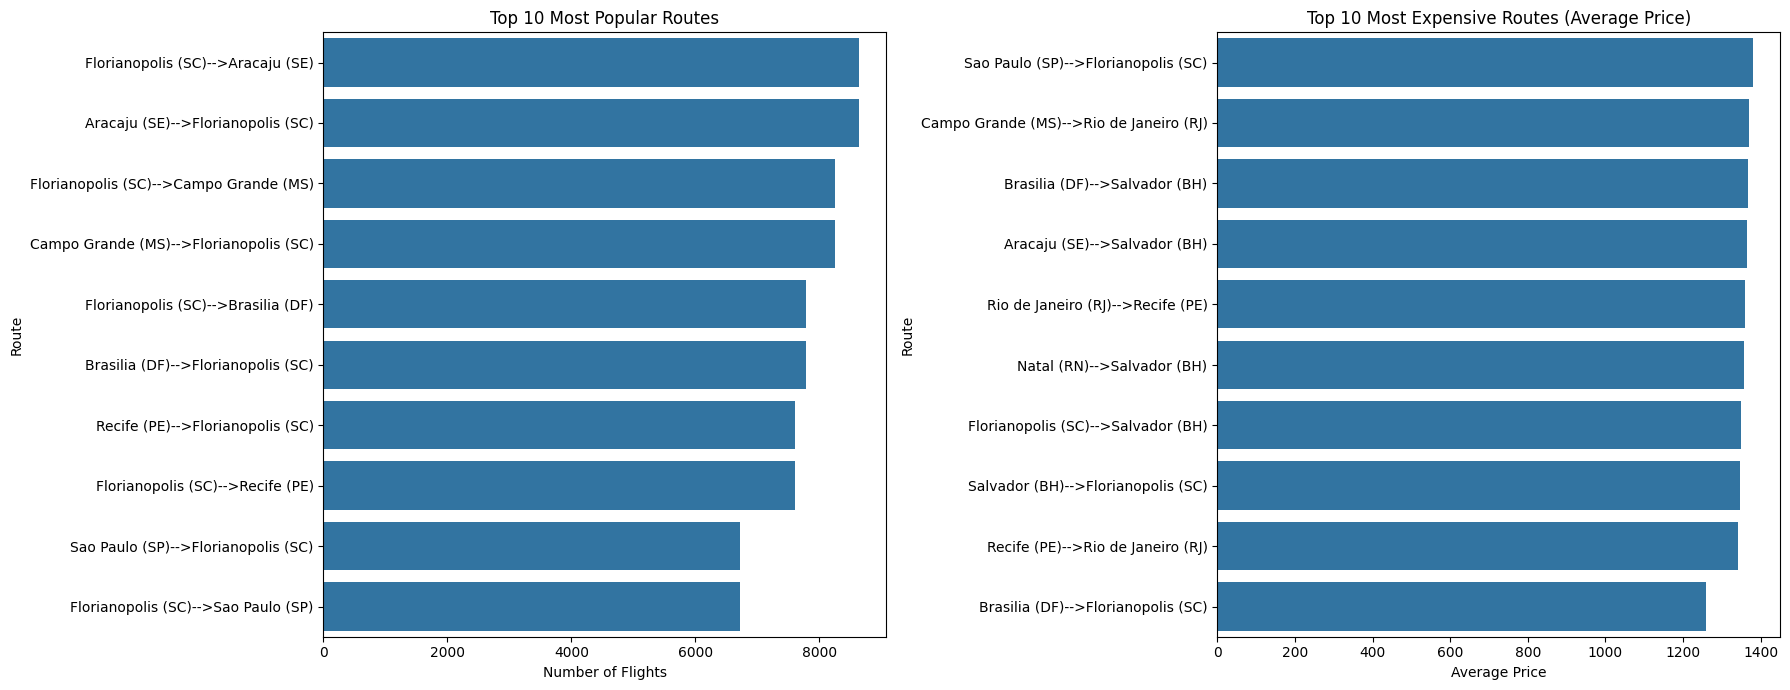

In [41]:
popular_routes = data['route'].value_counts().reset_index().head(10)
print(popular_routes)
print('                                                                     ')
route_price = data.groupby('route')['price'].mean().round().reset_index().sort_values('price',ascending = False,ignore_index = True).head(10)
print(route_price)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Most popular routes
sns.barplot(
    x='count',
    y='route',
    data=popular_routes,
    ax=axes[0]
)
axes[0].set_title('Top 10 Most Popular Routes')
axes[0].set_xlabel('Number of Flights')
axes[0].set_ylabel('Route')

# Plot 2: Most expensive routes (average price)
sns.barplot(
    x='price',
    y='route',
    data=route_price,
    ax=axes[1]
)
axes[1].set_title('Top 10 Most Expensive Routes (Average Price)')
axes[1].set_xlabel('Average Price')
axes[1].set_ylabel('Route')

plt.tight_layout()
plt.show()

###  **3. month(count) and month(price)**

   month_name  count
0     January  25587
1    February  22387
2       March  22741
3       April  22607
4         May  20968
5        June  19061
6        July  20113
7      August  17866
8   September  19468
9     October  28980
10   November  25764
11   December  26346
 
   month_name       price
0     January  24334010.0
1    February  21455154.0
2       March  21820448.0
3       April  21599833.0
4         May  20185236.0
5        June  18350698.0
6        July  19335078.0
7      August  17120034.0
8   September  18565907.0
9     October  27663041.0
10   November  24672329.0
11   December  25197016.0


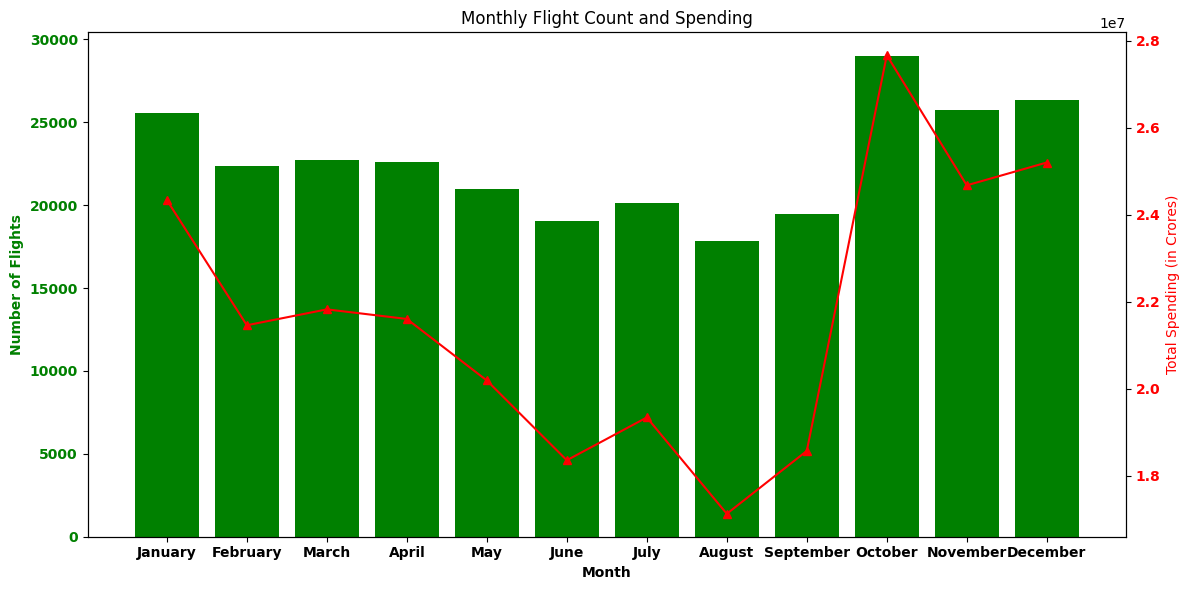

In [42]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_flight_count = data['month_name'].value_counts().reindex(month_order).reset_index()
print(monthly_flight_count)
print(' ')
monthly_spending = data.groupby('month_name')['price'].sum().round().reindex(month_order).reset_index()
print(monthly_spending)

# plot

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for monthly flight count
ax1.bar(monthly_flight_count['month_name'], monthly_flight_count['count'], color='green', label='Monthly Flight Count')

# X-axis values
ax1.set_xlabel('Month',fontweight='bold')
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

# left side y-axis
ax1.set_ylabel('Number of Flights',fontweight='bold', color='green')
for label in ax1.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('green')

# Create a second y-axis for monthly spending
ax2 = ax1.twinx()
ax2.plot(monthly_spending['month_name'], monthly_spending['price'], color='red', marker='^', label='Monthly Spending')

ax2.set_ylabel('Total Spending (in Crores)', color='red')
# right side y - axis
for label in ax2.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('red')

# Title and layout
plt.title('Monthly Flight Count and Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### **4. Weekly Flight Count & Weekly Spending**

   day_name   count
0    Monday   34108
1  Thursday  135944
2    Friday   33880
3  Saturday   33868
4    Sunday   34088
 
   day_name        price
0    Monday   33615912.0
1  Thursday  126458947.0
2    Friday   33304192.0
3  Saturday   33369349.0
4    Sunday   33550381.0


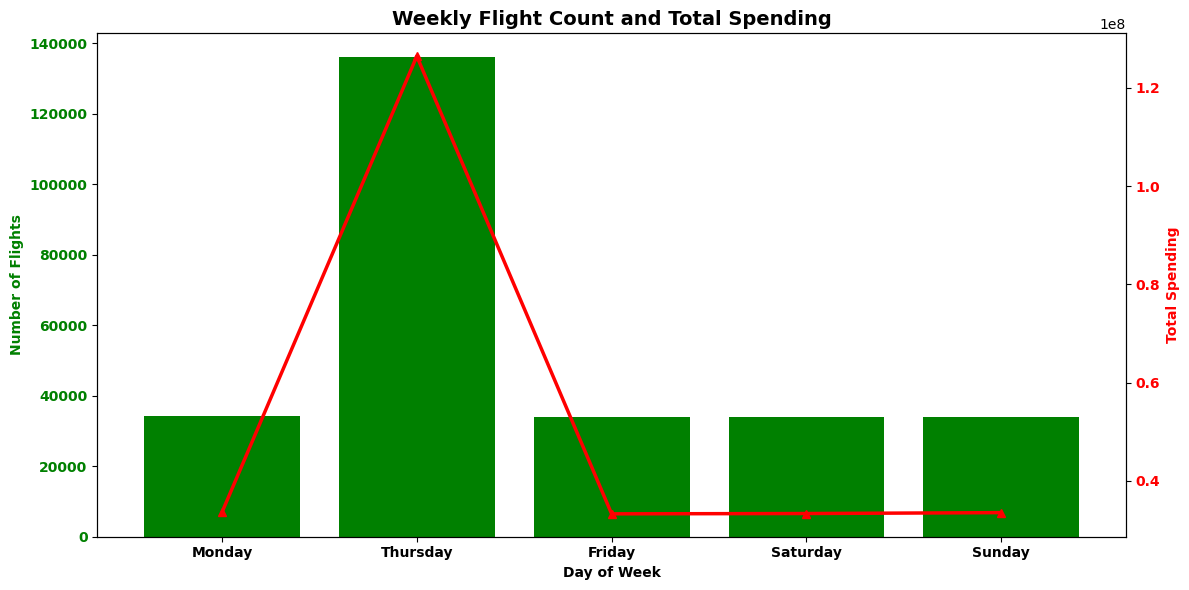

In [43]:
week_order = ['Monday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_flight_count = data['day_name'].value_counts().reindex(week_order).reset_index()
print(weekly_flight_count)
print(' ')
weekly_spending = data.groupby('day_name')['price'].sum().round().reindex(week_order).reset_index()
print(weekly_spending)

# plot
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot: Weekly flight count
ax1.bar(
    weekly_flight_count['day_name'],
    weekly_flight_count['count'],
    color='green',
    label='Weekly Flight Count'
)

# X-axis
ax1.set_xlabel('Day of Week', fontweight='bold')
for label in ax1.get_xticklabels():
    label.set_fontweight('bold')
    label.set_color('black')

# Left Y-axis (flight count)
ax1.set_ylabel('Number of Flights', fontweight='bold', color='green')
for label in ax1.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('green')

# Line plot: Weekly spending
ax2 = ax1.twinx()
ax2.plot(
    weekly_spending['day_name'],
    weekly_spending['price'],
    color='red',
    marker='^',
    linewidth=2.5,
    label='Weekly Spending'
)

# Right Y-axis (spending)
ax2.set_ylabel('Total Spending', fontweight='bold', color='red')
for label in ax2.get_yticklabels():
    label.set_fontweight('bold')
    label.set_color('red')

# Title
plt.title(
    'Weekly Flight Count and Total Spending',
    fontweight='bold',
    fontsize=14
)

plt.tight_layout()
plt.show()

In [44]:
monthly_flight_count = data['day_name'].value_counts()
print(monthly_flight_count)

day_name
Thursday    135944
Monday       34108
Sunday       34088
Friday       33880
Saturday     33868
Name: count, dtype: int64


### **5. flight type share and agency share**

  flight_type  percentage
0  firstClass       42.82
1     premium       28.69
2    economic       28.49

        agency  percentage
0      Rainbow       42.94
1      CloudFy       42.80
2  FlyingDrops       14.26


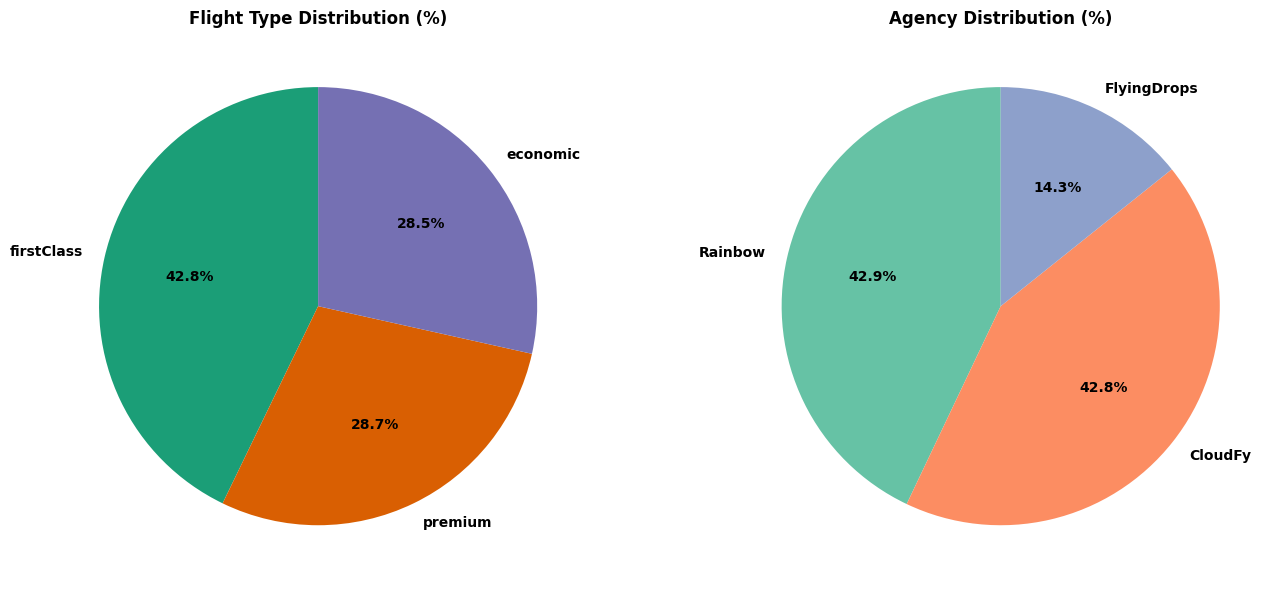

In [45]:
# flight type
flight_type_share = round(data['flightType'].value_counts()*100/data['flightType'].value_counts().sum(),2).reset_index()
flight_type_share.columns = ['flight_type','percentage']
print(flight_type_share)
print()

# agency
agency_share = round(data['agency'].value_counts()*100/data['agency'].value_counts().sum(),2).reset_index()
agency_share.columns = ['agency','percentage']
print(agency_share)


# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart 1: Flight Type Distribution
axes[0].pie(flight_type_share['percentage'],labels=flight_type_share['flight_type'],autopct='%1.1f%%',startangle=90,
            colors=plt.cm.Dark2.colors,textprops={'fontweight': 'bold'} )
axes[0].set_title('Flight Type Distribution (%)', fontweight='bold')

# Pie chart 2: Agency Distribution
axes[1].pie(agency_share['percentage'],labels=agency_share['agency'], autopct='%1.1f%%',startangle=90,
    colors=plt.cm.Set2.colors,textprops={'fontweight': 'bold'} )
axes[1].set_title('Agency Distribution (%)', fontweight='bold')

plt.tight_layout()
plt.show()

### **6. agency vs monthly flight count**

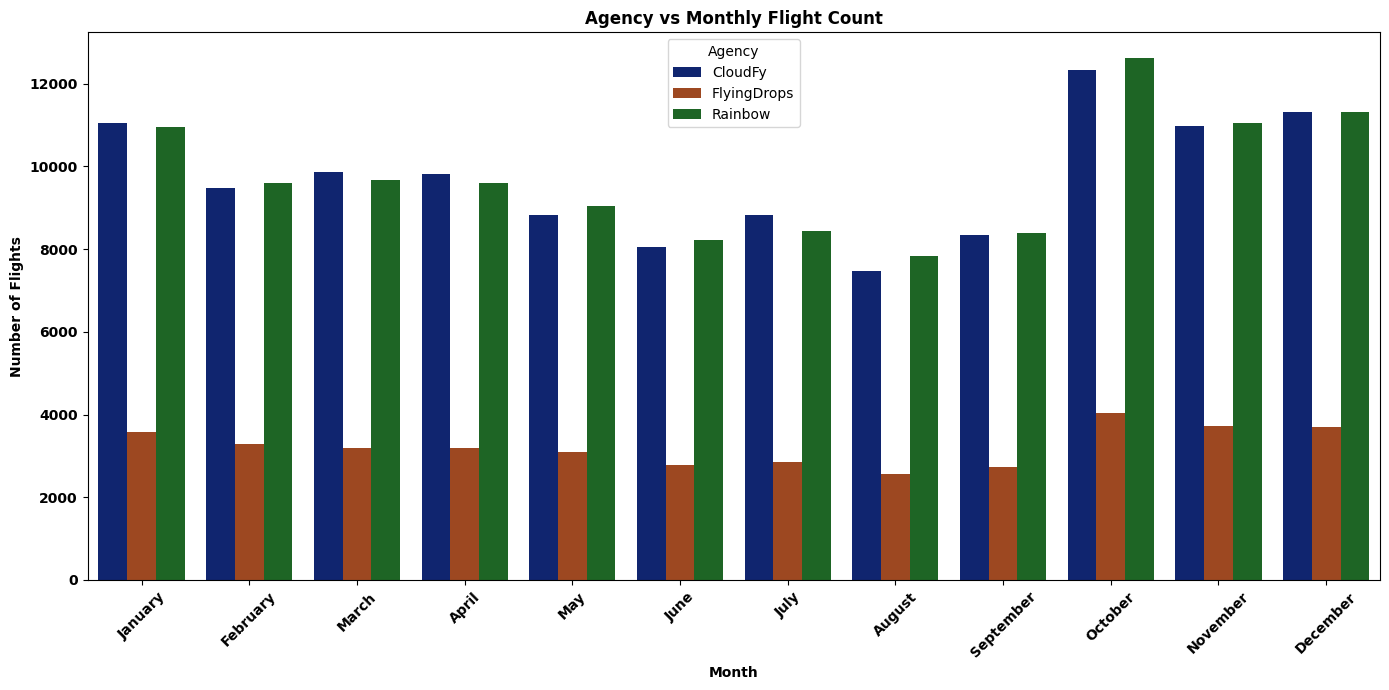

In [46]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

agency_month_count = data.groupby(['agency', 'month_name']).size().reset_index(name='flight_count')


# Keep months in correct order
agency_month_count['month_name'] = pd.Categorical(agency_month_count['month_name'],categories=month_order,ordered=True)
agency_month_count = agency_month_count.sort_values('month_name')

# bar plot

plt.figure(figsize=(14, 7))

sns.barplot(
    data=agency_month_count,
    x='month_name',
    y='flight_count',
    hue='agency',
    palette='dark'
)

plt.title('Agency vs Monthly Flight Count', fontweight='bold')
plt.xlabel('Month', fontweight='bold')
plt.ylabel('Number of Flights', fontweight='bold')

plt.xticks(rotation=45, fontweight='bold')
plt.yticks(fontweight='bold')

plt.legend(title='Agency')
plt.tight_layout()
plt.show()


### **7. Average Price and Price per Hour by Agency and Flight Type**

        agency  flightType        price
1      CloudFy  firstClass  1180.288168
2      CloudFy     premium   916.130745
0      CloudFy    economic   658.892160
3  FlyingDrops  firstClass  1186.160378
5      Rainbow  firstClass  1176.761172
6      Rainbow     premium   924.623086
4      Rainbow    economic   657.995808

        agency  flightType  price_for_hour
1      CloudFy  firstClass      901.547762
2      CloudFy     premium      701.154703
0      CloudFy    economic      506.812004
3  FlyingDrops  firstClass      900.462416
5      Rainbow  firstClass      904.031971
6      Rainbow     premium      698.538960
4      Rainbow    economic      506.197298


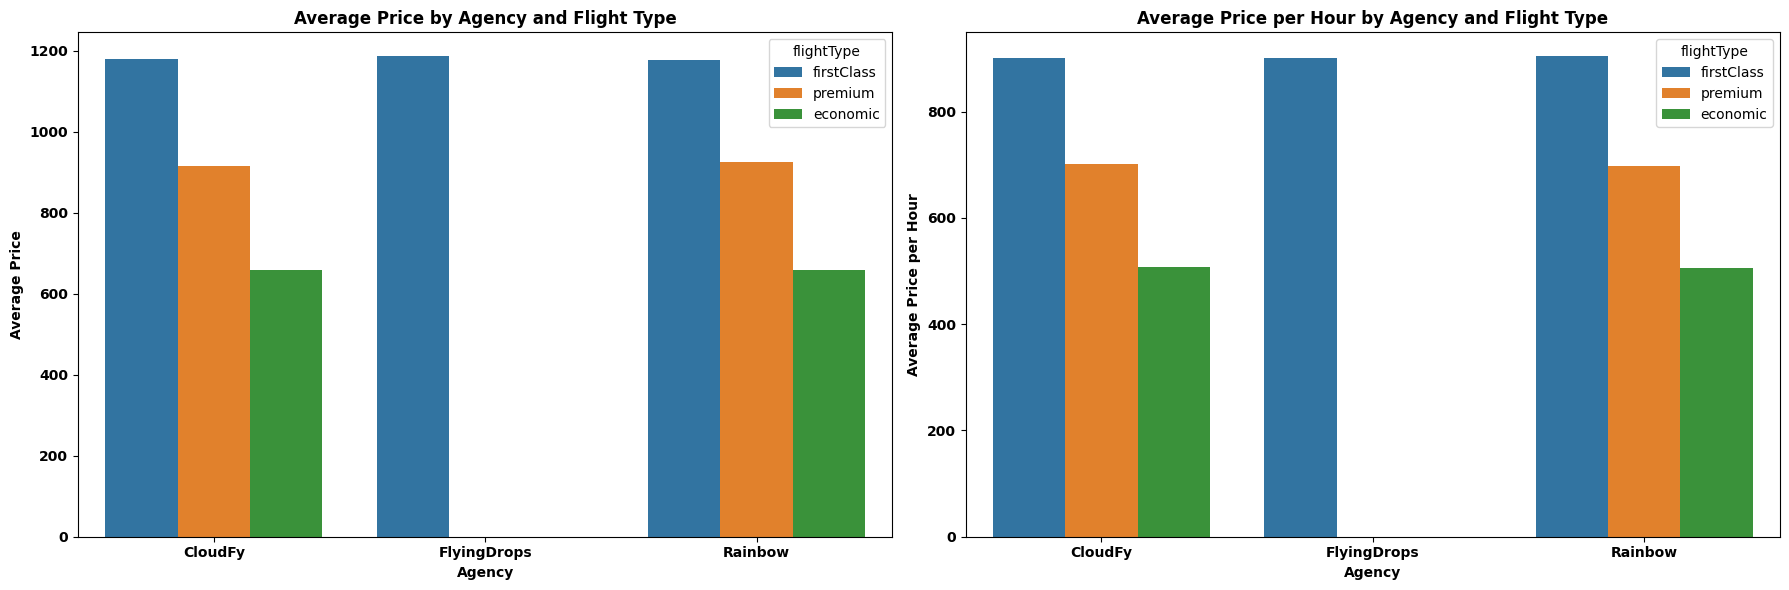

In [47]:
price_distribution = data.groupby(['agency', 'flightType'])['price'].mean().reset_index()
price_distribution = price_distribution.sort_values(['agency', 'price'], ascending=[True, False])
print(price_distribution)
print()

price_distribution_hour = data.groupby(['agency', 'flightType'])['price_for_hour'].mean().reset_index()
price_distribution_hour  = price_distribution_hour.sort_values(['agency', 'price_for_hour'], ascending=[True, False])
print(price_distribution_hour )

# plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1
sns.barplot(data=price_distribution,x='agency',y='price',hue='flightType',ax=axes[0])
axes[0].set_title('Average Price by Agency and Flight Type', fontweight='bold')
axes[0].set_xlabel('Agency', fontweight='bold')
axes[0].set_ylabel('Average Price', fontweight='bold')

# Plot 2
sns.barplot(data=price_distribution_hour,x='agency',y='price_for_hour',hue='flightType',ax=axes[1])
axes[1].set_title('Average Price per Hour by Agency and Flight Type', fontweight='bold')
axes[1].set_xlabel('Agency', fontweight='bold')
axes[1].set_ylabel('Average Price per Hour', fontweight='bold')

# Make tick labels bold
for ax in axes:
    for label in ax.get_xticklabels():
        label.set_fontweight('bold')
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')

plt.tight_layout()
plt.show()

In [48]:
#📌 Columns Dropped Before Training

# - userCode
# - travelCode
# - route (string column)
# - month_name
# - day_name
# - agency (dropped unless encoded)
# - from (raw categorical feature – encode first)
# - to (raw categorical feature – encode first)


In [49]:
# 7️⃣ Best EDA → Model Flow (Recommended)

# For EDA:
# - time_minutes
# - route
# - price_bucket
# - month_name
# - day_name

# 7️⃣  For Model:
# - time (hours)
# - distance
# - speed_km_per_hr
# - is_weekend
# - month
# - encoded agency
# - encoded flightType
# - price_per_km


In [50]:
# 1️⃣ Price-based Comparisons (MOST IMPORTANT)
# 🔹 Price vs Flight Type

# Insight: Is firstClass really expensive?

# Boxplot: price vs flightType

# Bar: avg price by flightType

# 🔹 Price vs Agency

# Insight: Which agency is costly / cheap?

# Bar chart: avg price by agency (top 10)

# Boxplot: price by agency

# 🔹 Price vs Distance

# Insight: Linear or non-linear relation?

# Scatter plot: distance vs price

# Add regression line

# 🔹 Price vs Time (Duration)

# Insight: Longer flights → higher price?

# Scatter: time vs price

# Scatter: minutes vs price (EDA only)

# 🔹 Price vs Route

# Insight: Which routes are expensive?

# Bar chart: avg price by route (top 10)

# Boxplot: price by route

# 2️⃣ Time & Date-based Comparisons 📅
# 🔹 Price vs Month

# Insight: Seasonal price changes?

# Line plot: avg price by month

# Boxplot: price vs month

# 🔹 Price vs Day of Week

# Insight: Weekend pricing?

# Bar: avg price by day_name

# Boxplot: price vs is_weekend

# 🔹 Flight Count vs Month

# Insight: Peak travel months?

# Countplot: flights per month

# 3️⃣ Duration & Distance Insights ✈️
# 🔹 Time vs Distance

# Insight: Data quality + speed pattern

# Scatter: distance vs time

# 🔹 Speed vs Flight Type

# Insight: FirstClass faster?

# Boxplot: speed vs flightType

# 🔹 Speed vs Agency

# Insight: Agency performance

# Boxplot: speed vs agency (top agencies)

# 4️⃣ Efficiency & Cost Metrics 💰
# 🔹 Price per KM vs Agency

# Insight: Cost efficiency

# Bar: avg price_per_km by agency

# 🔹 Price per Hour vs Flight Type

# Insight: Premium pricing logic

# Boxplot: price_for_hour vs flightType

# 5️⃣ Weekend vs Weekday Analysis 🗓️
# 🔹 Weekend vs Weekday Price

# Boxplot: price vs is_weekend

# Bar: avg price by is_weekend

# 🔹 Weekend vs Duration

# Boxplot: time vs is_weekend

# 6️⃣ Distribution & Outlier Analysis 📊
# 🔹 Price Distribution

# Histogram: price

# Boxplot: price

# 🔹 Time Distribution

# Histogram: time

# Histogram: minutes

# 🔹 Distance Distribution

# Histogram: distance

# 7️⃣ Correlation Analysis 🔥
# 🔹 Numeric Correlation Heatmap

# Include:

# price, time, distance, speed,
# month, day, is_weekend, agency_count

# 8️⃣ Recommended EDA Order (FOLLOW THIS)

# 1️⃣ Univariate (price, time, distance)
# 2️⃣ Price vs categorical
# 3️⃣ Price vs numeric
# 4️⃣ Time & seasonality
# 5️⃣ Efficiency metrics
# 6️⃣ Correlation heatmap

### **Feature Engineering & Data Pre-processing**

In [75]:
data_1 = ['from', 'to', 'flightType', 'price', 'time',
       'distance', 'agency','day','month',
       'is_weekend','speed'
       ]

data_clean = data[data_1].copy()

In [76]:
len(data_clean.columns)

11

### **1. outliers**

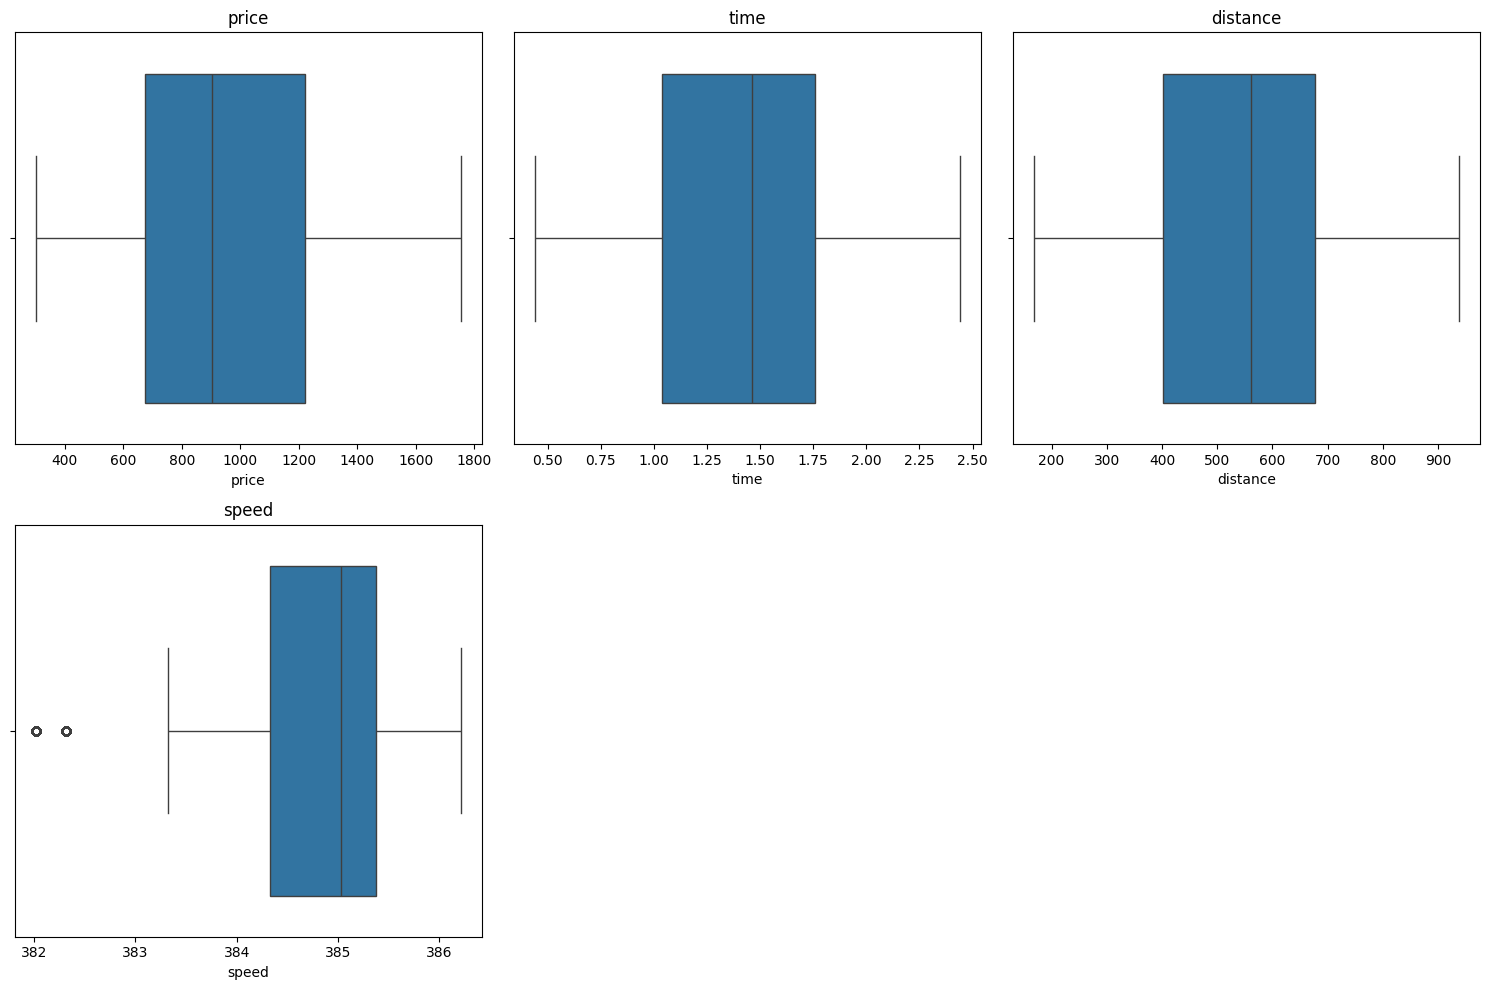

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical features to plot
numerical_features = ['price', 'time', 'distance', 'speed']

# Create a boxplot for each numerical feature
plt.figure(figsize=(15, 10))

for i, feature in enumerate(numerical_features):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(x=data[feature])
    plt.title(feature)

plt.tight_layout()
plt.show()


In [78]:


def remove_outliers(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter the dataframe to remove outliers
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    return df

In [79]:
# List of columns to check for outliers
columns_to_check = ['speed']

cleaned_data = remove_outliers(data_clean, columns_to_check)

In [80]:
data.shape[0]-cleaned_data.shape[0]  # outlier data

11182

### **2. Categorical Encoding**

In [81]:
categorical_small = ['from','to','flightType', 'agency']
data_encoded = pd.get_dummies(cleaned_data, columns=categorical_small, drop_first=True)
data_encoded.head(2)

,price,time,distance,day,month,is_weekend,speed,from_Brasilia (DF),from_Campo Grande (MS),from_Florianopolis (SC),from_Natal (RN),from_Recife (PE),from_Rio de Janeiro (RJ),from_Salvador (BH),from_Sao Paulo (SP),to_Brasilia (DF),to_Campo Grande (MS),to_Florianopolis (SC),to_Natal (RN),to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP),flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow
0,1434.38,1.76,676.53,3,9,1,384.392045,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False
1,1292.29,1.76,676.53,0,9,0,384.392045,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False


### **3. Data Scaling**

In [82]:
from sklearn.preprocessing import StandardScaler

# Select numerical columns for scaling
num_col = ['time'	,'distance'	,'day'	,'month'	,'is_weekend'	,'speed'	]

sclar = StandardScaler()
data_encoded[num_col] = sclar.fit_transform(data_encoded[num_col])

data_encoded.head(2)

,price,time,distance,day,month,is_weekend,speed,from_Brasilia (DF),from_Campo Grande (MS),from_Florianopolis (SC),from_Natal (RN),from_Recife (PE),from_Rio de Janeiro (RJ),from_Salvador (BH),from_Sao Paulo (SP),to_Brasilia (DF),to_Campo Grande (MS),to_Florianopolis (SC),to_Natal (RN),to_Recife (PE),to_Rio de Janeiro (RJ),to_Salvador (BH),to_Sao Paulo (SP),flightType_firstClass,flightType_premium,agency_FlyingDrops,agency_Rainbow
0,1434.38,0.577532,0.573187,-0.225880,0.663731,0.378665,-0.743887,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False
1,1292.29,0.577532,0.573187,-2.037879,0.663731,-2.640857,-0.743887,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,True,False


In [83]:
data_encoded.shape[0]

260706

### **4. data splitting**

In [84]:
from sklearn.model_selection import train_test_split

# Features and target
X  = data_encoded.drop('price',axis = 1)
y = data_encoded['price']

# Train-test split (80% train, 20% test)
X_train,X_test,y_train,y_test =  train_test_split(X,y,test_size = 0.2,random_state = 42)


In [85]:
print('x_train',len(X_train))
print('y_train',len(y_train))
print('x_test',len(X_test))
print('y_test',len(y_test))

x_train 208564
y_train 208564
x_test 52142
y_test 52142


# **ML_MODEL**

### **1. LINEAR REGRESSION**

In [86]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)

# predict values
y_pred = model.predict(X_test)
y_pred_train = model.predict(X_train)



In [87]:
print(y_pred.shape)
print(y_test.shape)
print(y_pred_train.shape)

(52142,)
(52142,)
(208564,)


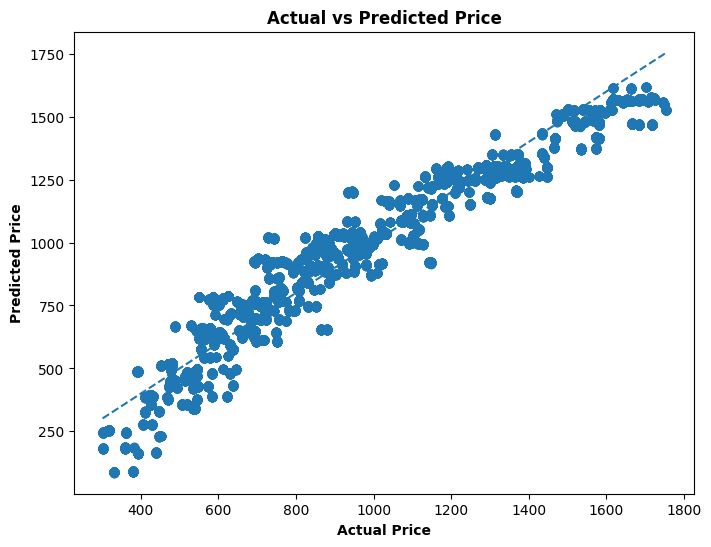

In [88]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Price", fontweight='bold')
plt.ylabel("Predicted Price", fontweight='bold')
plt.title("Actual vs Predicted Price", fontweight='bold')
plt.show()


In [89]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


R2 Score: 0.9242374019120849
MAE: 77.70361462524264
RMSE: 98.25442852710715


In [90]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_train = r2_score(y_train, y_pred_train)
mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))

print("TRAIN R2:", r2_train)
print("TRAIN MAE:", mae_train)
print("TRAIN RMSE:", rmse_train)


TRAIN R2: 0.9242860494517163
TRAIN MAE: 77.57194472725823
TRAIN RMSE: 98.04536953172428


RIDGE REGRESSION

In [91]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_train_ridge = ridge.predict(X_train)
y_pred_test_ridge = ridge.predict(X_test)


In [92]:
# Train metrics
train_r2 = r2_score(y_train, y_pred_train_ridge)
train_mae = mean_absolute_error(y_train, y_pred_train_ridge)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train_ridge))

# Test metrics
test_r2 = r2_score(y_test, y_pred_test_ridge)
test_mae = mean_absolute_error(y_test, y_pred_test_ridge)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_ridge))

print("TRAIN R²:", train_r2)
print("TRAIN MAE:", train_mae)
print("TRAIN RMSE:", train_rmse)

print("\nTEST R²:", test_r2)
print("TEST MAE:", test_mae)
print("TEST RMSE:", test_rmse)


TRAIN R²: 0.9236775479436151
TRAIN MAE: 78.16768294117333
TRAIN RMSE: 98.4385689551698

TEST R²: 0.9237045834425142
TEST MAE: 78.29343899066646
TEST RMSE: 98.59932200837763


In [93]:
import pandas as pd

comparison_results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "Train R²": [0.94908, train_r2],
    "Test R²": [0.94910, test_r2],
    "Test MAE": [61.98, test_mae],
    "Test RMSE": [81.29, test_rmse]
})

print(comparison_results)


               Model  Train R²   Test R²   Test MAE  Test RMSE
0  Linear Regression  0.949080  0.949100  61.980000  81.290000
1   Ridge Regression  0.923678  0.923705  78.293439  98.599322


### **XG BOOST**

In [94]:
from xgboost import XGBRegressor

In [96]:
xgb_model = XGBRegressor(
    n_estimators=100,      # number of trees
    learning_rate=0.1,     # step size shrinkage
    max_depth=5,           # max depth of each tree
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions on training and testing data
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)


In [97]:
# Evaluation metrics for training data
train_mae = mean_absolute_error(y_train, y_train_pred)
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred)

# Evaluation metrics for testing data
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

# Print all the metrics
print("Training Data Metrics:")
print(f"MAE: {train_mae}")
print(f"RMSE: {train_rmse}")
print(f"R² Score: {train_r2}\n")

print("Testing Data Metrics:")
print(f"MAE: {test_mae}")
print(f"RMSE: {test_rmse}")
print(f"R² Score: {test_r2}")

Training Data Metrics:
MAE: 18.724798968431763
RMSE: 23.12340044122971
R² Score: 0.9957886131956386

Testing Data Metrics:
MAE: 18.705024884462333
RMSE: 23.079449230973594
R² Score: 0.9958197575380335


In [98]:
import pickle

# Save the model to a file
filename = 'xgboost_model.pkl'
pickle.dump(xgb_model, open(filename, 'wb'))

print(f"Model saved as {filename}")

Model saved as xgboost_model.pkl


In [102]:
# dump scaler in pickle file
pickle.dump(sclar, open('scaler.pkl', 'wb'))
